# Supply Chain Analytics: Supply Chain Performance Analysis

Analysis Objective: To identify supply chain bottlenecks—in terms of delivery costs, lead times, defects, and product categories—and formulate recommendations for cost reduction.

Tools: Python (pandas, numpy, scipy, matplotlib, seaborn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

df = pd.read_excel('supply_chain_v2.xlsx')
print(df.head(5))
print(df.tail(5))

         Date            Product type        SKU   Price Availability  \
0  2023-01-01          Home & Kitchen  HOME-3011   59.99     In Stock   
1  2023-01-01                 Apparel  APPR-2005   44.99     In Stock   
2  2023-01-02  Beauty & Personal Care  BEAU-4012   22.99     In Stock   
3  2023-01-02                 Apparel  APPR-2009  119.99    Low Stock   
4  2023-01-02  Beauty & Personal Care  BEAU-4014   44.99     In Stock   

   Number of products sold  Revenue generated Customer demographics  \
0                       36            2159.64                 18-25   
1                       83            3734.17                   65+   
2                       21             482.79                 18-25   
3                       14            1679.86                 36-50   
4                       47            2114.53                   65+   

   Lead time  Shipping times  ... Shipping costs   Supplier name     Location  \
0         37              19  ...          16.25  Glo

In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df['Period'] = df['Date'].dt.to_period('M')

## 1. Data Preparation

Checking the dataset for missing data and duplicates.

In [3]:
df.isna().sum()

Date                       0
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Lead time                  0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
General Costs              0
Period                     0
dtype: int64

In [4]:
df.duplicated().sum()

0

In [5]:
df.describe()

,Date,Price,Number of products sold,Revenue generated,Lead time,Shipping times,Shipping costs,Manufacturing lead time,Manufacturing costs,Defect rates,General Costs
count,1000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2024-01-07 23:09:35.999999744,109.870000,46.747000,5107.91553,26.291000,14.067000,17.146120,17.422000,1532.656540,0.013647,1549.802660
min,2023-01-01 00:00:00,12.990000,3.000000,114.95000,7.000000,2.000000,4.450000,5.000000,30.260000,0.002500,49.450000
25%,2023-06-25 18:00:00,27.990000,23.000000,944.77500,16.000000,6.000000,9.345000,11.000000,246.312500,0.010275,260.107500
50%,2024-01-11 00:00:00,49.990000,37.000000,1921.98500,26.500000,11.000000,12.905000,18.000000,512.260000,0.013400,525.885000
75%,2024-07-29 06:00:00,89.990000,57.000000,4164.66500,36.000000,21.000000,19.470000,24.000000,1190.200000,0.016700,1201.202500
max,2024-12-31 00:00:00,1149.990000,542.000000,109598.63000,45.000000,44.000000,99.080000,30.000000,32228.090000,0.028100,32245.910000
std,NaN,188.059059,39.120012,10728.66399,11.245211,9.857062,11.948546,7.475815,3439.655802,0.004457,3440.383043


## 2. Exploratory Analysis (EDA)

We recalculate the lead time (the data is incorrectly calculated). We look at the basic statistics of key indicators.

In [6]:
df['Lead time'] = df['Shipping times'] + df['Manufacturing lead time']
df.head(5)

,Date,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Lead time,Shipping times,...,Supplier name,Location,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,General Costs,Period
0,2023-01-01,Home & Kitchen,HOME-3011,59.99,In Stock,36,2159.64,18-25,30,19,...,GlobalTech Ltd,China,11,703.65,Pass,0.0111,Rail,Domestic-EU,719.90,2023-01
1,2023-01-01,Apparel,APPR-2005,44.99,In Stock,83,3734.17,65+,36,7,...,FashionHub Inc,Vietnam,29,1096.98,Pass,0.0116,Air,EU-US,1123.46,2023-01
2,2023-01-02,Beauty & Personal Care,BEAU-4012,22.99,In Stock,21,482.79,18-25,43,30,...,CosmeticsPro,South Korea,13,107.46,Pass,0.0080,Air,Asia-AU,128.69,2023-01
3,2023-01-02,Apparel,APPR-2009,119.99,Low Stock,14,1679.86,36-50,49,25,...,FashionHub Inc,Vietnam,24,387.53,Pass,0.0147,Sea,EU-US,394.27,2023-01
4,2023-01-02,Beauty & Personal Care,BEAU-4014,44.99,In Stock,47,2114.53,65+,53,28,...,CosmeticsPro,South Korea,25,540.57,Pass,0.0083,Sea,Asia-EU,549.34,2023-01


In [7]:
df.describe()

,Date,Price,Number of products sold,Revenue generated,Lead time,Shipping times,Shipping costs,Manufacturing lead time,Manufacturing costs,Defect rates,General Costs
count,1000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2024-01-07 23:09:35.999999744,109.870000,46.747000,5107.91553,31.489000,14.067000,17.146120,17.422000,1532.656540,0.013647,1549.802660
min,2023-01-01 00:00:00,12.990000,3.000000,114.95000,7.000000,2.000000,4.450000,5.000000,30.260000,0.002500,49.450000
25%,2023-06-25 18:00:00,27.990000,23.000000,944.77500,22.000000,6.000000,9.345000,11.000000,246.312500,0.010275,260.107500
50%,2024-01-11 00:00:00,49.990000,37.000000,1921.98500,31.000000,11.000000,12.905000,18.000000,512.260000,0.013400,525.885000
75%,2024-07-29 06:00:00,89.990000,57.000000,4164.66500,39.000000,21.000000,19.470000,24.000000,1190.200000,0.016700,1201.202500
max,2024-12-31 00:00:00,1149.990000,542.000000,109598.63000,68.000000,44.000000,99.080000,30.000000,32228.090000,0.028100,32245.910000
std,NaN,188.059059,39.120012,10728.66399,12.369352,9.857062,11.948546,7.475815,3439.655802,0.004457,3440.383043


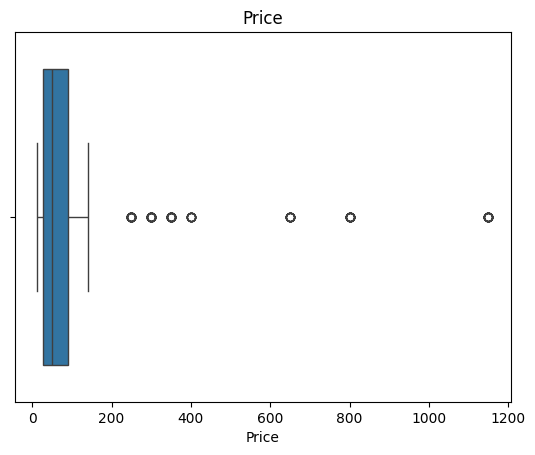

Skewness: 3.8934117763870244, Kurtosis: 16.420885981112136


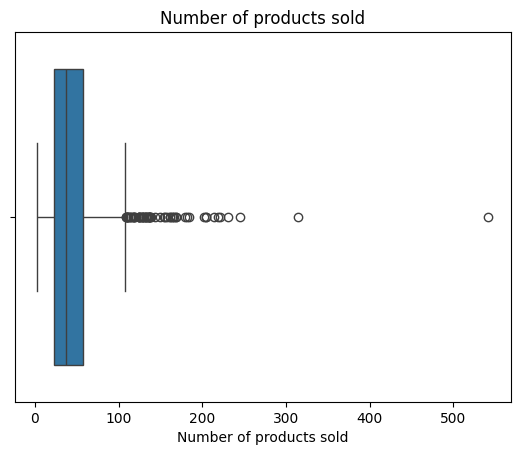

Skewness: 3.760878835160371, Kurtosis: 30.385219893612067


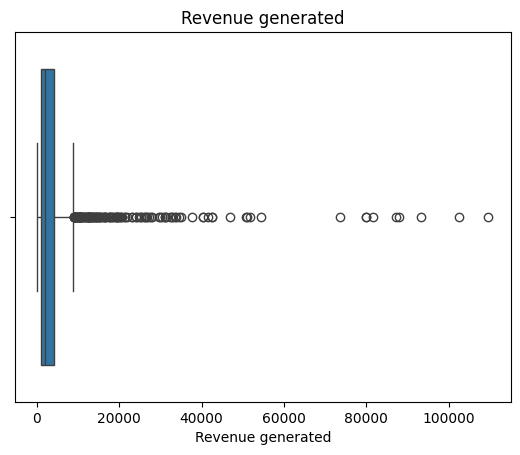

Skewness: 5.414927330758068, Kurtosis: 36.81239627277072


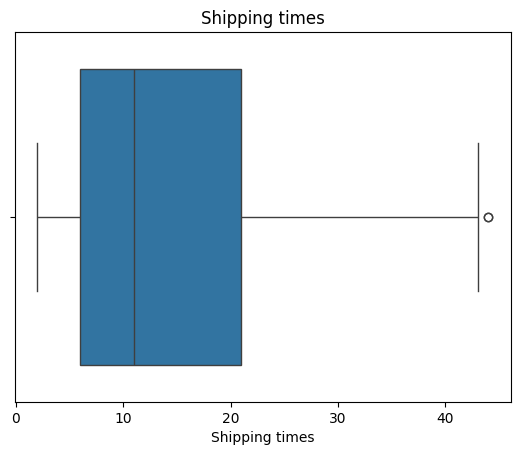

Skewness: 0.8026965683137111, Kurtosis: -0.2564701925544939


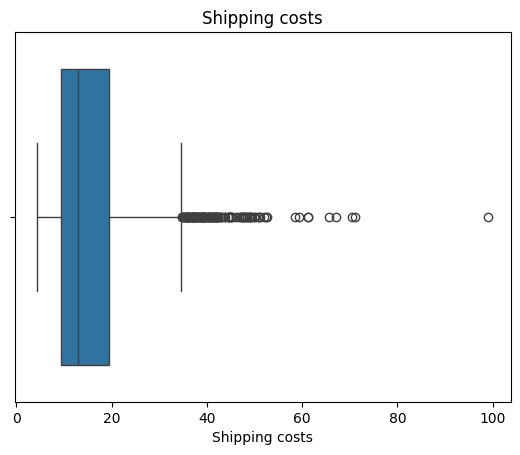

Skewness: 1.8224262199724677, Kurtosis: 3.984936092927686


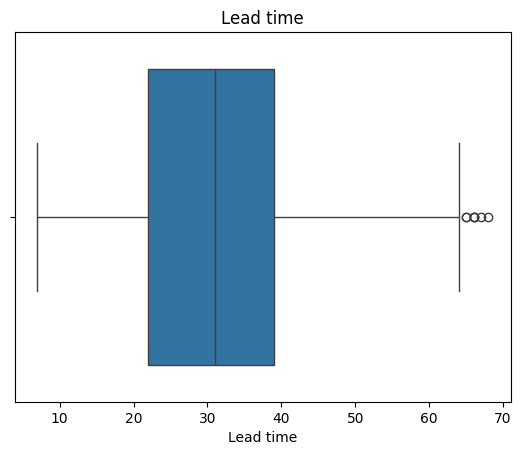

Skewness: 0.45633470156776645, Kurtosis: -0.17999444916379037


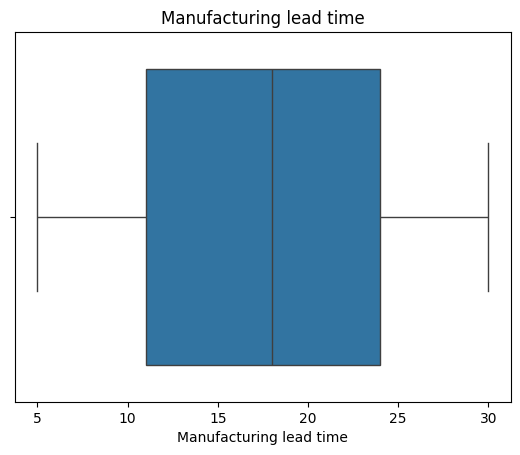

Skewness: 0.01844091723928259, Kurtosis: -1.2185781123458497


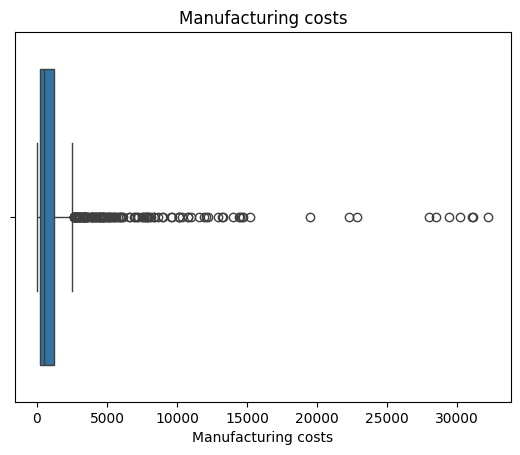

Skewness: 5.4896793163615305, Kurtosis: 37.15468486477759


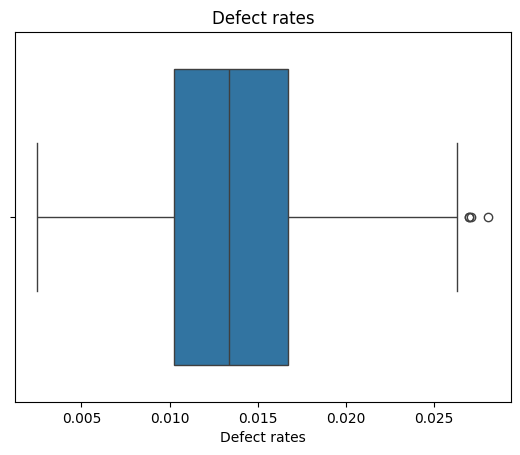

Skewness: 0.31777753218503896, Kurtosis: -0.3430178575946008


In [8]:
cols = ['Price', 'Number of products sold', 'Revenue generated', 'Shipping times', 
        'Shipping costs', 'Lead time', 'Manufacturing lead time', 
        'Manufacturing costs', 'Defect rates']

for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    print(f'Skewness: {df[col].skew()}, Kurtosis: {df[col].kurt()}')

### Distribution Interpretation

Boxplots show numerous outliers across most variables — this is expected 
for supply chain data. Large wholesale orders, route-specific costs, and 
supplier variability produce extreme values that reflect real business 
events, not data errors.

Skewness values confirm a mild right-skew for revenue and cost variables, 
consistent with a long-tail commercial distribution. In this case, I will not remove outliers.

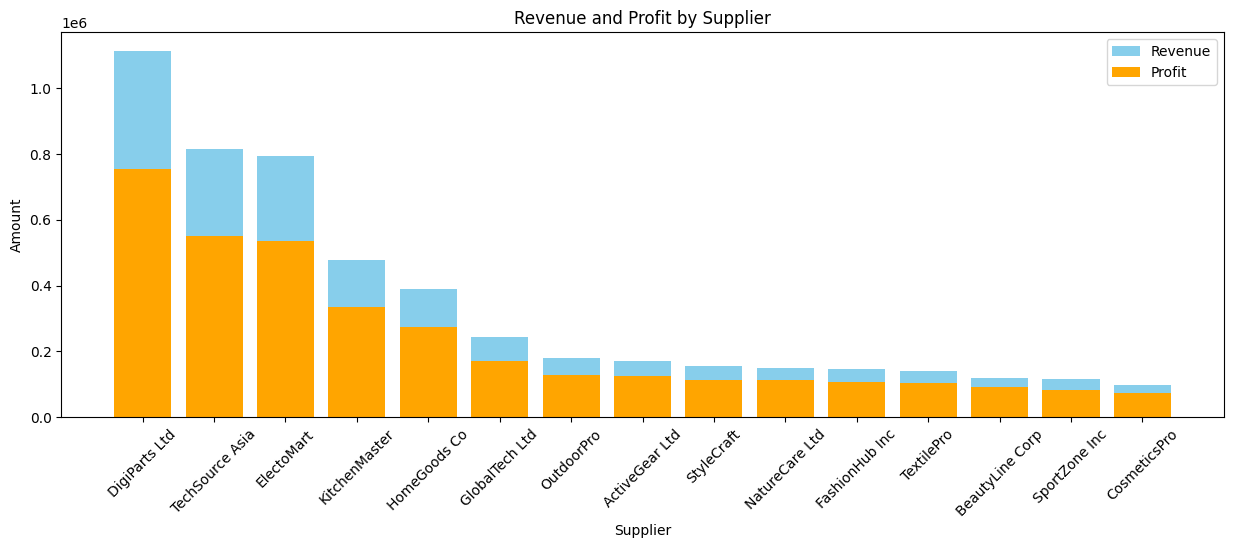

In [9]:
spul_rev = df.groupby('Supplier name')[['Revenue generated', 'General Costs']].sum().reset_index().sort_values(by='Revenue generated', ascending=False)
spul_rev['Profit'] = spul_rev['Revenue generated'] - spul_rev['General Costs']

plt.figure(figsize=(15, 5))
plt.bar(spul_rev['Supplier name'], spul_rev['Revenue generated'], color='skyblue', label='Revenue')
plt.bar(spul_rev['Supplier name'], spul_rev['Profit'], color='orange', label='Profit')

plt.xticks(rotation=45)
plt.title('Revenue and Profit by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Amount')
plt.legend()
plt.show()

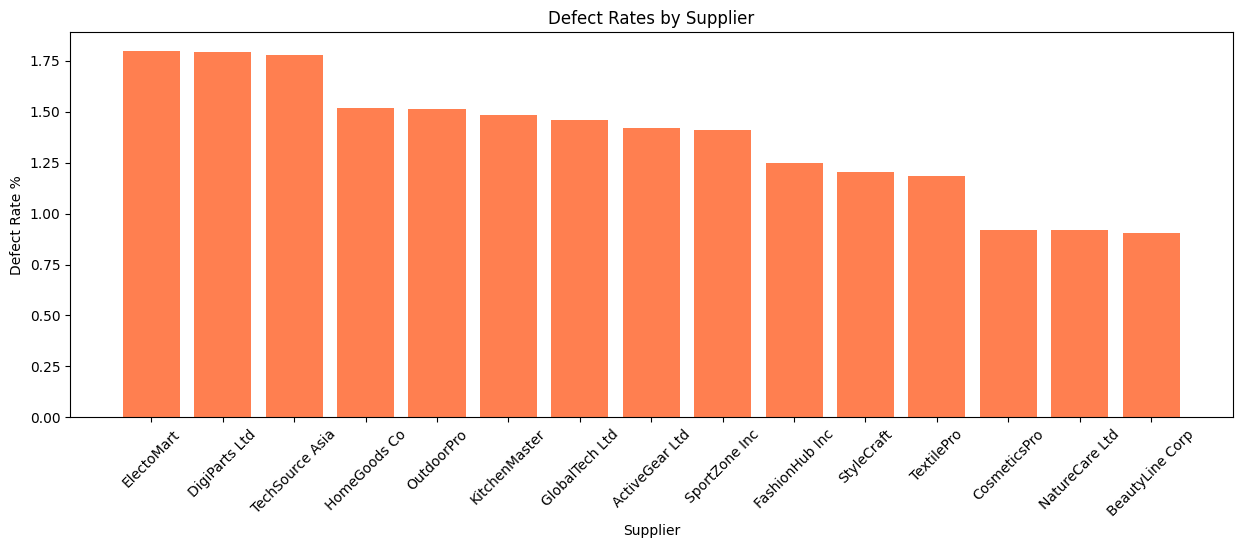

In [10]:
supl_DR = df.groupby('Supplier name')['Defect rates'].mean().mul(100).reset_index().sort_values(by='Defect rates', ascending=False)

plt.figure(figsize=(15, 5))
plt.bar(supl_DR['Supplier name'], supl_DR['Defect rates'], color='coral')
plt.title('Defect Rates by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Defect Rate %')
plt.xticks(rotation=45)
plt.show()

>Suppliers related to electronics more often supply materials with defects.

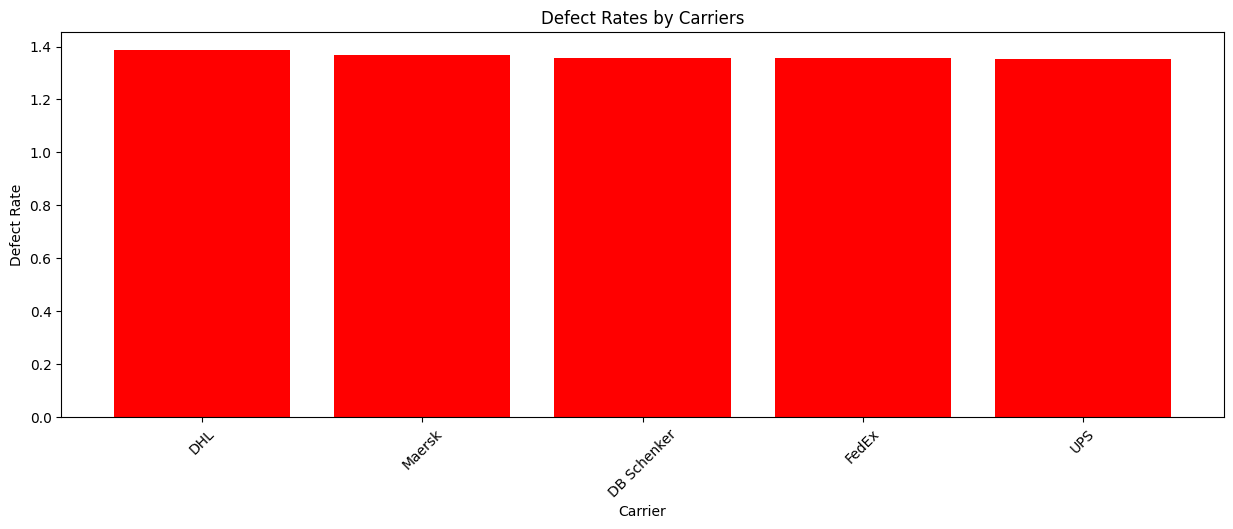

,Shipping carriers,Defect rates
1,DHL,1.386078
3,Maersk,1.369847
0,DB Schenker,1.357824
2,FedEx,1.356891
4,UPS,1.352804


In [11]:
carrier_DR = df.groupby('Shipping carriers')['Defect rates'].mean().mul(100).reset_index().sort_values(by='Defect rates', ascending=False)

plt.figure(figsize=(15, 5))
plt.bar(carrier_DR['Shipping carriers'], carrier_DR['Defect rates'], color='red')
plt.title('Defect Rates by Carriers')
plt.xlabel('Carrier')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45)
plt.show()
carrier_DR

> The percentage of defects among carriers is more or less the same.

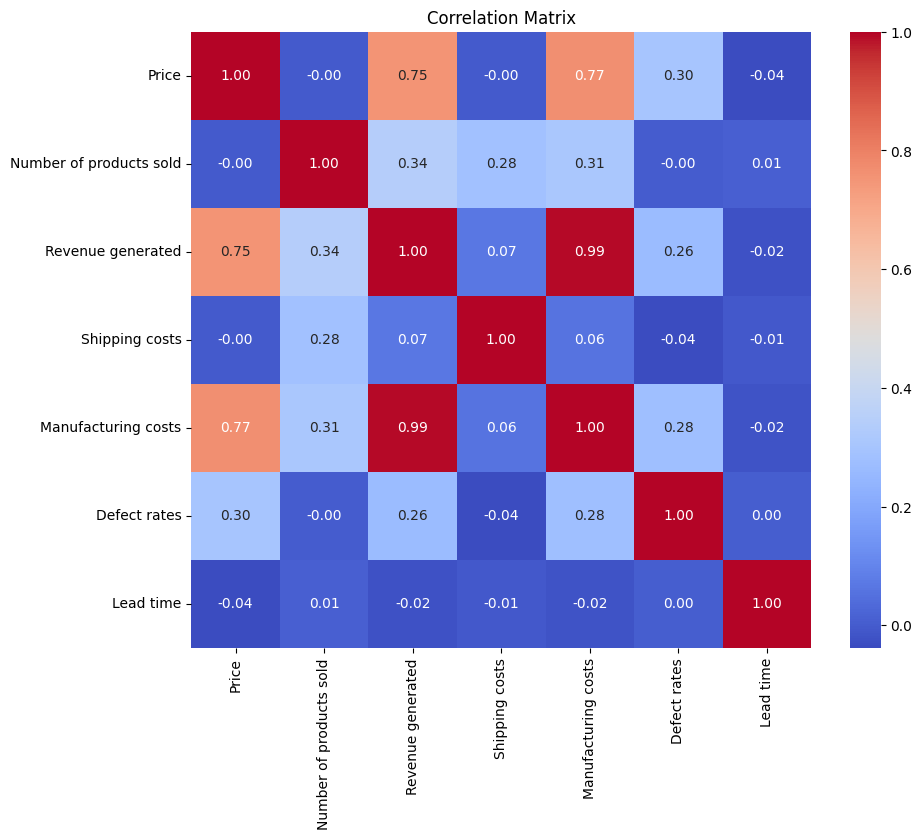

In [12]:
corr_cols = ['Price', 'Number of products sold', 'Revenue generated',
             'Shipping costs', 'Manufacturing costs', 'Defect rates', 'Lead time']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

> **The correlation matrix has important thing: manufacturing costs 
show a positive correlation with defect rates. This may indicate that 
complex or high-value products are harder to manufacture consistently, 
leading to higher defect rates — or alternatively, that quality control 
processes do not scale proportionally with production costs.**

## 3. Sales and Customer Segment Analysis

We determine which product categories and customer age groups generate the most revenue. This will help prioritize marketing and product range management.

In [13]:
df.groupby('Customer demographics')['Revenue generated'].sum().reset_index().sort_values(by='Revenue generated', ascending=False)

#The 65+ age group is the primary customer segment by revenue. 
#The 26–35 group underperforms relative to other segments, suggesting potential for targeted marketing intervention.

,Customer demographics,Revenue generated
4,65+,1206733.96
0,18-25,1100535.32
2,36-50,1069266.70
3,51-65,915699.70
1,26-35,815679.85


## 4. Operational Efficiency: Delivery Lead Time and Cost

**Task:** Find combinations of vehicle + route + carrier that provide the minimum lead time at the lowest cost.

The analysis is divided into three parts:
1. Logistics cost dynamics by month – have expenses increased?
2. Average lead time by transport mode and route
3. Delivery cost: carrier × vehicle × route

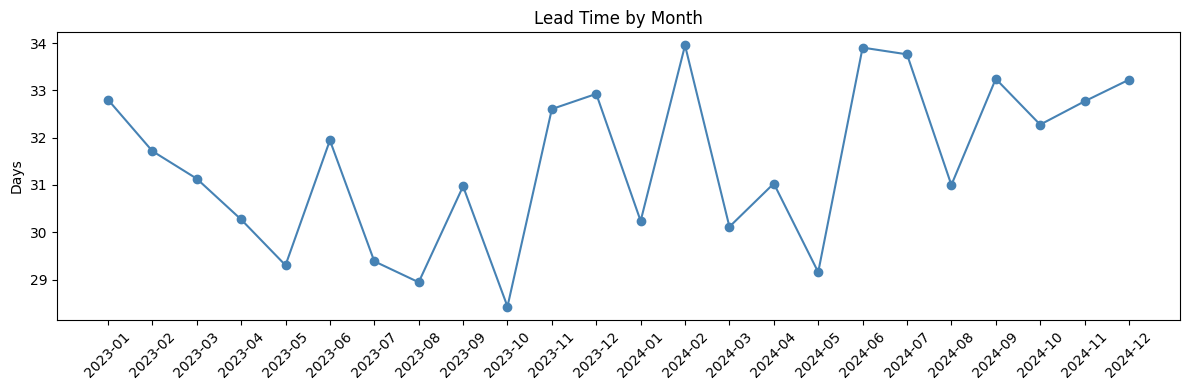

In [14]:
Period_LT = df.groupby('Period')['Lead time'].mean().reset_index()
Period_LT['Period'] = Period_LT['Period'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(Period_LT['Period'], Period_LT['Lead time'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Lead Time by Month')
plt.ylabel('Days')
plt.tight_layout()
plt.show()

In [15]:
year_2023 = df[df['Date'].dt.year == 2023]
year_2024 = df[df['Date'].dt.year == 2024]

stat, p_value = mannwhitneyu(year_2023['Shipping times'], year_2024['Shipping times'], alternative='two-sided')
print(f'Mann-Whitney U: stat={stat}, p-value={p_value}')
if p_value < 0.05:
    print('Conclusion: The difference is statistically significant')
else:
    print('Conclusion: Shipping times 2023 vs. 2024 — unchanged')

print('=====================================================================')

stat2, p_value2 = mannwhitneyu(year_2023['Shipping costs'], year_2024['Shipping costs'], alternative='two-sided')
print(f'Mann-Whitney U: stat={stat2}, p-value={p_value2}')
if p_value2 < 0.05:
    print('Conclusion: The difference is statistically significant')
else:
    print('Conclusion: Shipping costs 2023 vs. 2024 — unchanged')

Mann-Whitney U: stat=122923.5, p-value=0.6569667288820098
Conclusion: Shipping times 2023 vs. 2024 — unchanged
Mann-Whitney U: stat=124518.5, p-value=0.9247920930900099
Conclusion: Shipping costs 2023 vs. 2024 — unchanged


In [16]:
bang = df[df['Location'] == 'Bangladesh']['Manufacturing lead time']
ch = df[df['Location'] == 'China']['Manufacturing lead time']
fr = df[df['Location'] == 'France']['Manufacturing lead time']
grm = df[df['Location'] == 'Germany']['Manufacturing lead time']
ind = df[df['Location'] == 'India']['Manufacturing lead time']
mxc = df[df['Location'] == 'Mexico']['Manufacturing lead time']
southkor = df[df['Location'] == 'South Korea']['Manufacturing lead time']
twn = df[df['Location'] == 'Taiwan']['Manufacturing lead time']
usa = df[df['Location'] == 'USA']['Manufacturing lead time']
vietnm = df[df['Location'] == 'Vietnam']['Manufacturing lead time']

_, p_value = stats.f_oneway(bang, ch, fr, grm, ind, mxc, southkor, twn, usa, vietnm)

print("p-value:", p_value)

df.groupby('Location')['Manufacturing lead time'].median().reset_index()

p-value: 0.33233223791033173


,Location,Manufacturing lead time
0,Bangladesh,18.0
1,China,19.0
2,France,18.0
3,Germany,16.0
4,India,15.0
5,Mexico,19.0
6,South Korea,17.0
7,Taiwan,18.0
8,USA,16.0
9,Vietnam,19.5


> There is no statistical significance between locations in terms of manufacturing time.

In [17]:
bang = df[df['Location'] == 'Bangladesh']['Shipping times']
ch = df[df['Location'] == 'China']['Shipping times']
fr = df[df['Location'] == 'France']['Shipping times']
grm = df[df['Location'] == 'Germany']['Shipping times']
ind = df[df['Location'] == 'India']['Shipping times']
mxc = df[df['Location'] == 'Mexico']['Shipping times']
southkor = df[df['Location'] == 'South Korea']['Shipping times']
twn = df[df['Location'] == 'Taiwan']['Shipping times']
usa = df[df['Location'] == 'USA']['Shipping times']
vietnm = df[df['Location'] == 'Vietnam']['Shipping times']

_, p_value = stats.f_oneway(bang, ch, fr, grm, ind, mxc, southkor, twn, usa, vietnm)

print("p-value:", p_value)

#There is also no statistical significance in terms of shipping time between locations.

p-value: 0.6224312963554566


> There is no statistical significance between locations in terms of shipping time.

In [18]:
df.pivot_table(
    index='Supplier name',
    values=['Lead time'],
    columns='Location',
    aggfunc='mean'
)

Lead time                                              \
Location        Bangladesh      China     France    Germany      India   
Supplier name                                                            
ActiveGear Ltd         NaN  31.333333        NaN        NaN        NaN   
BeautyLine Corp        NaN        NaN  30.069444        NaN        NaN   
CosmeticsPro           NaN        NaN        NaN        NaN        NaN   
DigiParts Ltd          NaN        NaN        NaN        NaN        NaN   
ElectoMart             NaN        NaN        NaN        NaN        NaN   
FashionHub Inc         NaN        NaN        NaN        NaN        NaN   
GlobalTech Ltd         NaN  31.490566        NaN        NaN        NaN   
HomeGoods Co           NaN        NaN        NaN        NaN        NaN   
KitchenMaster          NaN        NaN        NaN  32.472973        NaN   
NatureCare Ltd         NaN        NaN        NaN        NaN        NaN   
OutdoorPro             NaN        NaN        NaN  32.289855        NaN   
SportZone Inc          NaN        NaN        NaN        NaN        NaN   
StyleCraft             NaN        NaN        NaN        NaN  29.909091   
TechSource Asia        NaN  31.983607        NaN        NaN        NaN   
TextilePro       31.359375        NaN        NaN        NaN        NaN   

                                                                        
Location            Mexico South Korea     Taiwan        USA   Vietnam  
Supplier name                                                           
ActiveGear Ltd         NaN         NaN        NaN        NaN       NaN  
BeautyLine Corp        NaN         NaN        NaN        NaN       NaN  
CosmeticsPro           NaN   33.109091        NaN        NaN       NaN  
DigiParts Ltd          NaN         NaN  32.044118        NaN       NaN  
ElectoMart             NaN   31.166667        NaN        NaN       NaN  
FashionHub Inc         NaN         NaN        NaN        NaN  33.09375  
GlobalTech Ltd         NaN         NaN        NaN        NaN       NaN  
HomeGoods Co     30.884058         NaN        NaN        NaN       NaN  
KitchenMaster          NaN         NaN        NaN        NaN       NaN  
NatureCare Ltd         NaN         NaN        NaN  31.562500       NaN  
OutdoorPro             NaN         NaN        NaN        NaN       NaN  
SportZone Inc          NaN         NaN        NaN  30.123077       NaN  
StyleCraft             NaN         NaN        NaN        NaN       NaN  
TechSource Asia        NaN         NaN        NaN        NaN       NaN  
TextilePro             NaN         NaN        NaN        NaN       NaN

In [19]:
df.groupby('Routes')[['Lead time', 'Shipping costs']].mean()

,Lead time,Shipping costs
Routes,,
Asia-AU,31.272727,20.080802
Asia-EU,31.289157,18.368494
Asia-US,30.972222,17.750069
Domestic-EU,31.522013,13.112013
Domestic-US,30.648148,13.074815
EU-US,33.021978,19.686264


In [20]:
df.groupby('Transportation modes')[['Lead time', 'Shipping times', 'Shipping costs']].mean()

,Lead time,Shipping times,Shipping costs
Transportation modes,,,
Air,31.630137,14.561644,36.642785
Rail,30.895349,14.023256,11.383721
Road,30.980676,13.260870,14.105652
Sea,31.927861,14.231343,10.555920


## 🔍 Hypothesis: Can We Replace Air Shipping with Sea Without Losing Speed?

Descriptive statistics show that **Air** and **Sea** transportation have surprisingly similar Lead Times and Shipping times,
yet their shipping costs differ dramatically. Before making any recommendation,
I need to verify whether this difference in Lead Time is **statistically significant** —
or just noise in the data.

**Approach:**
- Compare Shipping times distributions for Air vs Sea using a statistical test
- If the difference is NOT significant → Sea shipping is equally fast, but cheaper
- Quantify the potential cost savings using Bootstrap simulation

> If the null hypothesis holds (no real difference in speed), switching 75% of Air shipments to Sea - this is a reasonable cost optimization.

In [28]:
df.groupby('Transportation modes')[['Lead time','Shipping times', 'Shipping costs']].mean()

air = df[df['Transportation modes'] == 'Air']['Shipping times']
sea = df[df['Transportation modes'] == 'Sea']['Shipping times']

stat, p_value = mannwhitneyu(air, sea, alternative='two-sided')
print(f'Mann-Whitney U: stat={stat}, p-value={p_value}')

if p_value < 0.05:
    print('Conclusion: The difference is statistically significant')
else:
    print('Conclusion: The difference is NOT significant - shipping times between Air and Sea are the same')

Mann-Whitney U: stat=44884.5, p-value=0.6852946595882027
Conclusion: The difference is NOT significant - shipping times between Air and Sea are the same


In [29]:
df.pivot_table(
    index='Transportation modes',
    values=['Lead time'],
    columns='Routes',
    aggfunc='mean'
)

Lead time                                                \
Routes                  Asia-AU    Asia-EU    Asia-US Domestic-EU Domestic-US   
Transportation modes                                                            
Air                   31.222222  33.400000  30.600000         NaN         NaN   
Rail                        NaN  30.172414        NaN   31.719298   30.807018   
Road                        NaN        NaN        NaN   31.411765   30.561905   
Sea                   31.304348  30.809524  31.115385         NaN         NaN   

                                 
Routes                    EU-US  
Transportation modes             
Air                   31.483871  
Rail                        NaN  
Road                        NaN  
Sea                   33.816667

In [30]:
df.groupby(['Shipping carriers', 'Routes'])[['Lead time', 'Shipping costs']].mean()

Lead time  Shipping costs
Shipping carriers Routes                                
DB Schenker       Asia-AU      34.114286       16.159143
                  Asia-EU      32.448276       21.112759
                  Asia-US      31.478261       22.515217
                  Domestic-EU  30.062500       12.648750
                  Domestic-US  28.972973       12.783514
                  EU-US        35.324324       18.698649
DHL               Asia-AU      32.454545       25.100682
                  Asia-EU      31.393939       21.037273
                  Asia-US      30.828571       13.956857
                  Domestic-EU  29.562500       14.488750
                  Domestic-US  28.863636       14.574545
                  EU-US        33.552632       21.305000
FedEx             Asia-AU      28.823529       15.549118
                  Asia-EU      32.026316       18.302105
                  Asia-US      32.450000       18.071500
                  Domestic-EU  32.037037       13.102963
                  Domestic-US  32.631579       13.847895
                  EU-US        33.972222       17.758056
Maersk            Asia-AU      29.621622       20.127027
                  Asia-EU      29.419355       16.569355
                  Asia-US      26.629630       18.946667
                  Domestic-EU  30.933333       12.093333
                  Domestic-US  31.000000       13.103636
                  EU-US        31.789474       17.827105
UPS               Asia-AU      31.081081       21.938919
                  Asia-EU      31.085714       15.244000
                  Asia-US      33.051282       17.350769
                  Domestic-EU  34.500000       13.153421
                  Domestic-US  31.093750       11.432813
                  EU-US        30.212121       23.173939

In [31]:
df.pivot_table(
    index=['Shipping carriers','Transportation modes'],
    values=['Shipping costs'],
    columns='Routes',
    aggfunc='mean'
)

Shipping costs                        \
Routes                                        Asia-AU    Asia-EU    Asia-US   
Shipping carriers Transportation modes                                        
DB Schenker       Air                       31.898000  40.104000  38.392000   
                  Rail                            NaN  10.313750        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                        9.863600  11.701818  10.302308   
DHL               Air                       37.748333  40.085000  32.794000   
                  Rail                            NaN  12.535714        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                        9.923500  13.097778  10.817333   
FedEx             Air                       34.637143  37.970000  37.738000   
                  Rail                            NaN  10.993750        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       10.600370   9.992632  11.516000   
Maersk            Air                       33.067500  35.723750  33.268000   
                  Rail                            NaN  11.116364        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       10.267619   8.798333  10.522353   
UPS               Air                       36.347333  33.796667  38.456000   
                  Rail                            NaN  12.158824        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       12.115000  10.338333  10.073103   

                                                                           
Routes                                 Domestic-EU Domestic-US      EU-US  
Shipping carriers Transportation modes                                     
DB Schenker       Air                          NaN         NaN  33.358462  
                  Rail                   12.326000   11.000769        NaN  
                  Road                   12.795455   13.749167        NaN  
                  Sea                          NaN         NaN  10.757917  
DHL               Air                          NaN         NaN  41.631538  
                  Rail                   12.699167   12.692857        NaN  
                  Road                   15.562500   15.452667        NaN  
                  Sea                          NaN         NaN  10.735200  
FedEx             Air                          NaN         NaN  35.838000  
                  Rail                   11.218462   11.250667        NaN  
                  Road                   14.852857   15.541739        NaN  
                  Sea                          NaN         NaN  10.804231  
Maersk            Air                          NaN         NaN  33.381538  
                  Rail                    9.412857    9.863333        NaN  
                  Road                   12.909130   14.318750        NaN  
                  Sea                          NaN         NaN   9.738800  
UPS               Air                          NaN         NaN  42.609231  
                  Rail                   11.831333    9.909231        NaN  
                  Road                   14.015652   12.475263        NaN  
                  Sea                          NaN         NaN  10.541000

In [32]:
df.pivot_table(
    index=['Shipping carriers','Transportation modes'],
    values=['Shipping times'],
    columns='Routes',
    aggfunc='mean'
)

Shipping times                        \
Routes                                        Asia-AU    Asia-EU    Asia-US   
Shipping carriers Transportation modes                                        
DB Schenker       Air                       20.200000  14.100000  15.700000   
                  Rail                            NaN  12.250000        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       13.800000  16.454545  14.538462   
DHL               Air                       15.375000  16.900000  16.800000   
                  Rail                            NaN  13.857143        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       15.350000  10.666667  10.666667   
FedEx             Air                       14.000000  13.636364  16.000000   
                  Rail                            NaN  11.000000        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       11.925926  17.052632  15.333333   
Maersk            Air                       13.812500  13.250000  12.300000   
                  Rail                            NaN  16.181818        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       14.095238  13.250000   9.941176   
UPS               Air                       12.333333  20.833333  13.700000   
                  Rail                            NaN  12.117647        NaN   
                  Road                            NaN        NaN        NaN   
                  Sea                       14.636364  10.250000  16.137931   

                                                                           
Routes                                 Domestic-EU Domestic-US      EU-US  
Shipping carriers Transportation modes                                     
DB Schenker       Air                          NaN         NaN  14.692308  
                  Rail                   12.800000   14.461538        NaN  
                  Road                   14.863636   12.041667        NaN  
                  Sea                          NaN         NaN  18.500000  
DHL               Air                          NaN         NaN  13.076923  
                  Rail                   11.583333   14.571429        NaN  
                  Road                   13.050000   12.200000        NaN  
                  Sea                          NaN         NaN  15.920000  
FedEx             Air                          NaN         NaN  15.200000  
                  Rail                   13.000000   14.733333        NaN  
                  Road                    9.785714   12.869565        NaN  
                  Sea                          NaN         NaN  16.615385  
Maersk            Air                          NaN         NaN  12.461538  
                  Rail                   16.857143   11.222222        NaN  
                  Road                   12.782609   12.958333        NaN  
                  Sea                          NaN         NaN  15.320000  
UPS               Air                          NaN         NaN  12.846154  
                  Rail                   18.400000   15.846154        NaN  
                  Road                   16.260870   14.368421        NaN  
                  Sea                          NaN         NaN  10.650000

## 5. Scenario Analysis: What If We Shift 75% of Air Shipments to Sea?

We've already confirmed statistically that Air and Sea Lead Times are **not significantly different**.
This means speed is not a valid reason to prefer Air over Sea - so the business case for switching is solid.

**Method: Bootstrap Simulation (10,000 iterations)**

Rather than calculating a single savings estimate, Bootstrap resamples the actual cost data
repeatedly to model the full range of realistic outcomes. This gives us not just a number —
but a **confidence interval** we can trust.

> 💡 95% of the time the actual savings would fall within this range.


Savings (Bootstrap median): 4,279.09
95% CI: (4,044.36 — 4,501.38)


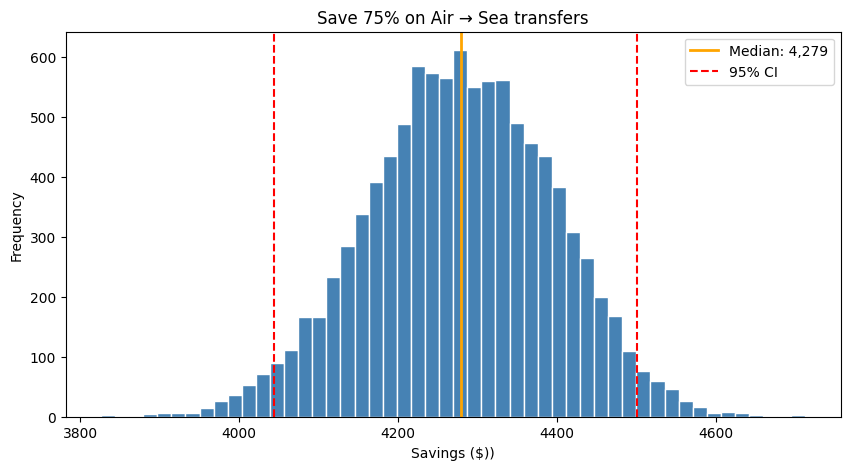

In [33]:
np.random.seed(42)
n_simulations = 10000

air_costs = df[df['Transportation modes'] == 'Air']['Shipping costs'].values
sea_costs = df[df['Transportation modes'] == 'Sea']['Shipping costs'].values

air_n = df[df['Transportation modes'] == 'Air']['Shipping costs'].count()
sea_n = df[df['Transportation modes'] == 'Sea']['Shipping costs'].count()

air_n_25pr = round(air_n*0.25)
sea_n_pc_of_air = round(sea_n + (air_n*0.75))

savings = []
before = air_costs.sum() + sea_costs.sum()

for _ in range(n_simulations):
    remaining_air = np.random.choice(air_costs, size=air_n_25pr, replace=True)  
    new_sea_sample = np.random.choice(sea_costs, size=sea_n_pc_of_air, replace=True)
    after = remaining_air.sum() + new_sea_sample.sum()
    savings.append(before - after)

savings = np.array(savings)
print(f'\nSavings (Bootstrap median): {np.median(savings):,.2f}')
print(f'95% CI: ({np.percentile(savings, 2.5):,.2f} — {np.percentile(savings, 97.5):,.2f})')


plt.figure(figsize=(10, 5))
plt.hist(savings, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.median(savings), color='orange', linewidth=2, label=f'Median: {np.median(savings):,.0f}')
plt.axvline(np.percentile(savings, 2.5), color='red', linestyle='--', label='95% CI')
plt.axvline(np.percentile(savings, 97.5), color='red', linestyle='--')
plt.title('Save 75% on Air → Sea transfers')
plt.xlabel('Savings ($))')
plt.ylabel('Frequency')
plt.legend()
plt.show()


---

## 🏁 Conclusions & Business Recommendations

### 📊 Key Insights

| Area | Finding | Implication |
|------|---------|-------------|
| 🚢 Transportation | Air vs Sea shipping times are statistically identical (p=0.68), yet Air costs 3.5x more (36.6 vs 10.56 USD) | No business justification to use Air over Sea |
| 💰 Cost Simulation | Shifting 75% of Air to Sea saves 4,279.09 USD median (95% CI: 4,044.36 — 4,501.38 USD) | High-confidence, data-backed savings opportunity |
| ⚠️ Product Quality | Electronics/Technics show the highest defect rate across all categories | Supplier quality controls need strengthening |
| 📈 Correlations | Price-Revenue (strong), Units sold-Mfg costs (strong), Mfg costs-Defect rate (moderate) | Higher-cost production does not guarantee quality |
| 📅 Stability | Lead Time and Shipping costs unchanged YoY | Supply chain is stable, no hidden degradation |
| 👥 Customer Segments | Top revenue: 65+ (1.2M USD) and 18–25 (1.1M USD). Weakest: 26–35 (815K USD) | Segment 26–35 is underperforming its potential |

---

### 💡 Recommendations

> **1. 🚢 Shift 75% of Air shipments to Sea**
> Statistically equivalent speed, ~4,279.09 USD in projected savings. Low risk, high reward.

> **2. 📦 Optimize carrier selection per route**
> Cost differences between carriers on the same route are significant — standardize on cheapest per lane.

> **3. 🔬 Strengthen Electronics quality controls**
> Highest defect rate = highest hidden cost. Invest in supplier audits or incoming inspection.

> **4. 🎯 Develop a targeted strategy for the 26–35 segment**
> Lowest revenue despite being a high-spending demographic elsewhere. Untapped growth potential.